In [1]:
import pandas as pd

flights_df = pd.read_csv('../data/flights/Clean_Dataset.csv')

print("Shape:", flights_df.shape)
print(flights_df.head())
print("\nColumns:", flights_df.columns.tolist())
print("\nMissing values:\n", flights_df.isnull().sum())

Shape: (300153, 12)
   Unnamed: 0   airline   flight source_city departure_time stops  \
0           0  SpiceJet  SG-8709       Delhi        Evening  zero   
1           1  SpiceJet  SG-8157       Delhi  Early_Morning  zero   
2           2   AirAsia   I5-764       Delhi  Early_Morning  zero   
3           3   Vistara   UK-995       Delhi        Morning  zero   
4           4   Vistara   UK-963       Delhi        Morning  zero   

    arrival_time destination_city    class  duration  days_left  price  
0          Night           Mumbai  Economy      2.17          1   5953  
1        Morning           Mumbai  Economy      2.33          1   5953  
2  Early_Morning           Mumbai  Economy      2.17          1   5956  
3      Afternoon           Mumbai  Economy      2.25          1   5955  
4        Morning           Mumbai  Economy      2.33          1   5955  

Columns: ['Unnamed: 0', 'airline', 'flight', 'source_city', 'departure_time', 'stops', 'arrival_time', 'destination_city', 'cl

In [2]:
# Drop the leftover index column
flights_df = flights_df.drop(columns=['Unnamed: 0'])

# Encode all text/categorical columns into numbers
categorical_cols = ['airline', 'source_city', 'departure_time', 'stops', 'arrival_time', 'destination_city', 'class']

for col in categorical_cols:
    flights_df[col + '_encoded'] = flights_df[col].astype('category').cat.codes

# Check the result
print(flights_df[[c + '_encoded' for c in categorical_cols] + ['duration', 'days_left', 'price']].head())
print("\nShape after encoding:", flights_df.shape)

   airline_encoded  source_city_encoded  departure_time_encoded  \
0                4                    2                       2   
1                4                    2                       1   
2                0                    2                       1   
3                5                    2                       4   
4                5                    2                       4   

   stops_encoded  arrival_time_encoded  destination_city_encoded  \
0              2                     5                         5   
1              2                     4                         5   
2              2                     1                         5   
3              2                     0                         5   
4              2                     4                         5   

   class_encoded  duration  days_left  price  
0              1      2.17          1   5953  
1              1      2.33          1   5953  
2              1      2.17          1   5956  


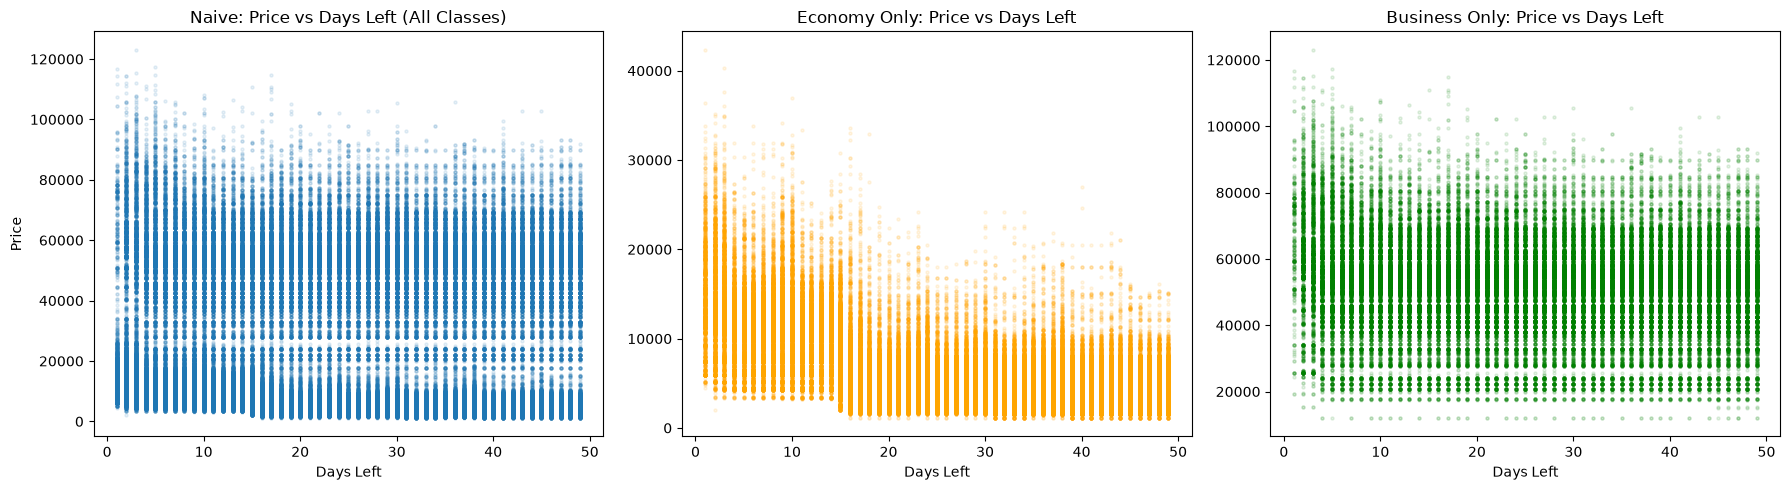

Correlation - days_left vs price (all classes): -0.09194853217143828
Correlation - days_left vs price (economy only): -0.5595514473411392
Correlation - days_left vs price (business only): -0.09128941558253953


In [3]:
import matplotlib.pyplot as plt

economy_data = flights_df[flights_df['class'] == 'Economy']
business_data = flights_df[flights_df['class'] == 'Business']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(flights_df['days_left'], flights_df['price'], alpha=0.1, s=5)
axes[0].set_title('Naive: Price vs Days Left (All Classes)')
axes[0].set_xlabel('Days Left')
axes[0].set_ylabel('Price')

axes[1].scatter(economy_data['days_left'], economy_data['price'], alpha=0.1, s=5, color='orange')
axes[1].set_title('Economy Only: Price vs Days Left')
axes[1].set_xlabel('Days Left')

axes[2].scatter(business_data['days_left'], business_data['price'], alpha=0.1, s=5, color='green')
axes[2].set_title('Business Only: Price vs Days Left')
axes[2].set_xlabel('Days Left')

plt.tight_layout()
plt.savefig('../notebooks/confounding_check_flights.png', dpi=150)
plt.show()

print("Correlation - days_left vs price (all classes):", flights_df['days_left'].corr(flights_df['price']))
print("Correlation - days_left vs price (economy only):", economy_data['days_left'].corr(economy_data['price']))
print("Correlation - days_left vs price (business only):", business_data['days_left'].corr(business_data['price']))

In [4]:
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, r2_score

# Select features
flight_feature_cols = [
    'airline_encoded', 'source_city_encoded', 'departure_time_encoded',
    'stops_encoded', 'arrival_time_encoded', 'destination_city_encoded',
    'class_encoded', 'duration', 'days_left'
]

X_flights = flights_df[flight_feature_cols]
y_flights = flights_df['price']

X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_flights, y_flights, test_size=0.2, random_state=42
)

# Train
model_flights = xgb.XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42)
model_flights.fit(X_train_f, y_train_f)

# Evaluate
y_pred_f = model_flights.predict(X_test_f)
mae_f = mean_absolute_error(y_test_f, y_pred_f)
r2_f = r2_score(y_test_f, y_pred_f)

print(f"Flights Model — MAE: ₹{mae_f:.2f}  |  R²: {r2_f:.4f}")

# Feature importance
import pandas as pd
importance_f = pd.DataFrame({
    'feature': flight_feature_cols,
    'importance': model_flights.feature_importances_
}).sort_values('importance', ascending=False)

print("\nFeature importance:")
print(importance_f)

Flights Model — MAE: ₹2382.71  |  R²: 0.9668

Feature importance:
                    feature  importance
6             class_encoded    0.954219
7                  duration    0.013587
8                 days_left    0.009076
0           airline_encoded    0.007193
3             stops_encoded    0.004797
1       source_city_encoded    0.003586
5  destination_city_encoded    0.003385
4      arrival_time_encoded    0.002628
2    departure_time_encoded    0.001529


In [5]:
dynamic_flight_cols = [
    'airline_encoded', 'source_city_encoded', 'departure_time_encoded',
    'stops_encoded', 'arrival_time_encoded', 'destination_city_encoded',
    'duration', 'days_left'
]

X_dyn_f = flights_df[dynamic_flight_cols]
y_dyn_f = flights_df['price']

X_train_dyn_f, X_test_dyn_f, y_train_dyn_f, y_test_dyn_f = train_test_split(
    X_dyn_f, y_dyn_f, test_size=0.2, random_state=42
)

model_dyn_flights = xgb.XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42)
model_dyn_flights.fit(X_train_dyn_f, y_train_dyn_f)

y_pred_dyn_f = model_dyn_flights.predict(X_test_dyn_f)
mae_dyn_f = mean_absolute_error(y_test_dyn_f, y_pred_dyn_f)
r2_dyn_f = r2_score(y_test_dyn_f, y_pred_dyn_f)

print(f"Flights Dynamic-Only Model — MAE: ₹{mae_dyn_f:.2f}  |  R²: {r2_dyn_f:.4f}")

Flights Dynamic-Only Model — MAE: ₹14894.31  |  R²: 0.3173


In [6]:
flights_df.to_csv('../data/flights/flights_cleaned_features.csv', index=False)
print("Saved! Shape:", flights_df.shape)

Saved! Shape: (300153, 18)


In [7]:
import shap

explainer_flights = shap.TreeExplainer(model_flights)

sample_flights = X_test_f.sample(n=1000, random_state=42)
shap_values_flights = explainer_flights.shap_values(sample_flights)

print("SHAP values shape:", shap_values_flights.shape)


c:\Users\Paras\Desktop\dynamic-pricing-genai\dynamic-pricing-genai\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP values shape: (1000, 9)


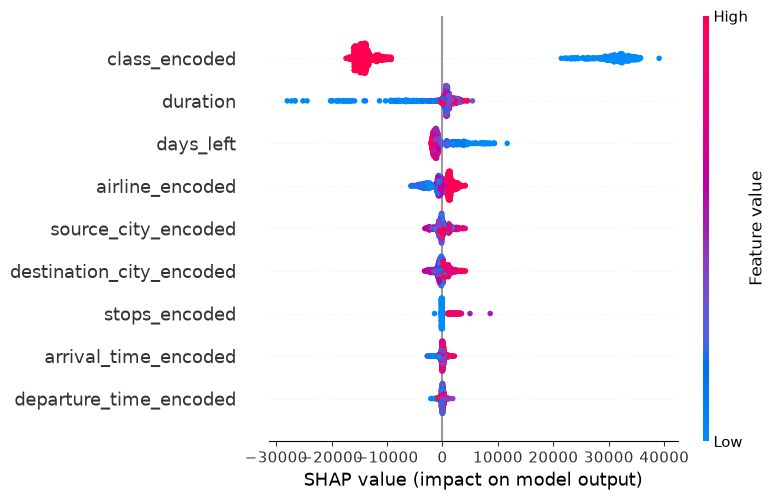

In [8]:
shap.summary_plot(shap_values_flights, sample_flights, show=False)
plt.tight_layout()
plt.savefig('../notebooks/shap_summary_flights.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
def explain_prediction(row_index, X_data, shap_vals, base_value):
    """Get the top contributing features for a single prediction."""
    row_shap = shap_vals[row_index]
    feature_names = X_data.columns
    
    contributions = sorted(
        zip(feature_names, row_shap),
        key=lambda x: abs(x[1]),
        reverse=True
    )
    
    print(f"Base price (average): ₹{base_value:.2f}")
    print(f"Actual predicted price: ₹{base_value + row_shap.sum():.2f}\n")
    print("Top contributing factors:")
    for feature, contribution in contributions[:3]:
        direction = "increased" if contribution > 0 else "decreased"
        print(f"  {feature}: {direction} price by ₹{abs(contribution):.2f}")

explain_prediction(0, sample_flights, shap_values_flights, explainer_flights.expected_value)

Base price (average): ₹20888.57
Actual predicted price: ₹11325.32

Top contributing factors:
  class_encoded: decreased price by ₹14653.47
  days_left: increased price by ₹3874.85
  airline_encoded: increased price by ₹1516.44


In [10]:
model_lower_f = xgb.XGBRegressor(
    objective='reg:quantileerror', quantile_alpha=0.1,
    n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42
)
model_lower_f.fit(X_train_f, y_train_f)

model_upper_f = xgb.XGBRegressor(
    objective='reg:quantileerror', quantile_alpha=0.9,
    n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42
)
model_upper_f.fit(X_train_f, y_train_f)

sample_test_f = X_test_f.iloc[:5]
point_pred_f = model_flights.predict(sample_test_f)
lower_pred_f = model_lower_f.predict(sample_test_f)
upper_pred_f = model_upper_f.predict(sample_test_f)

for i in range(5):
    print(f"Predicted: ₹{point_pred_f[i]:.2f}  |  Range: ₹{lower_pred_f[i]:.2f} - ₹{upper_pred_f[i]:.2f}")

lower_all_f = model_lower_f.predict(X_test_f)
upper_all_f = model_upper_f.predict(X_test_f)
within_range_f = ((y_test_f >= lower_all_f) & (y_test_f <= upper_all_f)).mean()
print(f"\n% of actual prices within predicted range: {within_range_f*100:.1f}%")

Predicted: ₹5449.63  |  Range: ₹4028.72 - ₹12481.38
Predicted: ₹68305.13  |  Range: ₹50678.14 - ₹70961.87
Predicted: ₹6625.73  |  Range: ₹5371.74 - ₹13231.15
Predicted: ₹55651.95  |  Range: ₹42699.57 - ₹62634.41
Predicted: ₹5938.84  |  Range: ₹3816.29 - ₹12979.04

% of actual prices within predicted range: 90.3%


In [11]:
import joblib

joblib.dump(model_flights, '../model/flights_price_model.pkl')
joblib.dump(model_lower_f, '../model/flights_price_model_lower.pkl')
joblib.dump(model_upper_f, '../model/flights_price_model_upper.pkl')
joblib.dump(explainer_flights, '../model/flights_shap_explainer.pkl')
joblib.dump(flight_feature_cols, '../model/flights_feature_cols.pkl')

print("All flights model artifacts saved to ../model/")

All flights model artifacts saved to ../model/
